In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Embedding, Dropout,GlobalAveragePooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import BatchNormalization
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
import seaborn as sns
import os
import re
import nltk
# Tải bộ công cụ xử lý ngôn ngữ tự nhiên
#nltk.download("punkt")
#nltk.download('punkt_tab')

2025-04-28 08:25:19.670282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745828719.837047      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745828719.882390      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
df = pd.read_csv("/kaggle/input/sql-injection/clean_sql_dataset.csv")

print(df.head())
print(df.info())
print(df['Label'].value_counts())

                                               Query  Label
0                  " or pg_sleep  (  __TIME__  )  --      1
1  create user name identified by pass123 tempora...      1
2   AND 1  =  utl_inaddr.get_host_address   (    ...      1
3   select * from users where id  =  '1' or @ @1 ...      1
4   select * from users where id  =  1 or 1#"  ( ...      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148326 entries, 0 to 148325
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Query   148326 non-null  object
 1   Label   148326 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 2.3+ MB
None
Label
1    77750
0    70576
Name: count, dtype: int64


In [3]:
df = df.drop_duplicates()
df = df.dropna(subset=['Query'])

print(f"Số lượng dữ liệu sau khi làm sạch: {len(df)}")
print(df['Label'].value_counts())

Số lượng dữ liệu sau khi làm sạch: 148326
Label
1    77750
0    70576
Name: count, dtype: int64


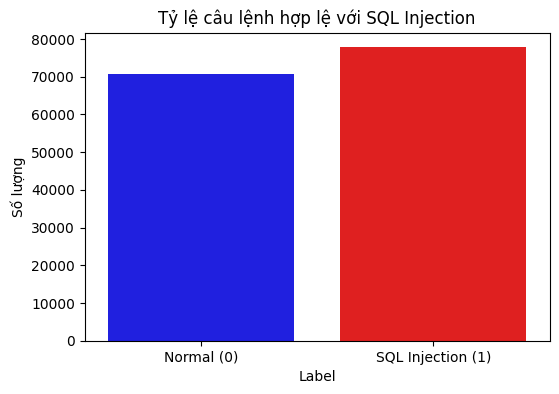

In [4]:
"""#Tỷ lệ câu lệnh hợp lệ với SQL Injection
plt.figure(figsize=(6,4))
sns.countplot(x=df["Label"], palette=["blue", "red"])
plt.xticks([0,1], ["Normal (0)", "SQL Injection (1)"])
plt.ylabel("Số lượng")
plt.title("Tỷ lệ câu lệnh hợp lệ với SQL Injection")
plt.show()
#"""

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


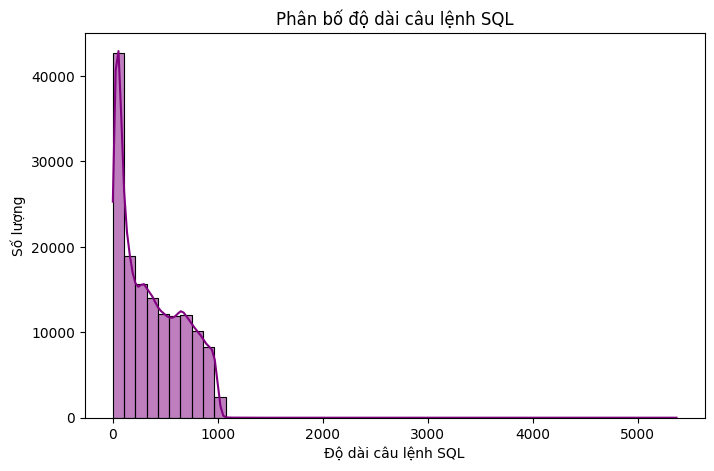

In [5]:
"""# Phân bố độ dài câu lệnh SQL
df["Query_Length"] = df["Query"].apply(len)
df["Query_Length"] = df["Query_Length"].replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["Query_Length"])
plt.figure(figsize=(8,5))
sns.histplot(df["Query_Length"], bins=50, kde=True, color='purple')
plt.xlabel("Độ dài câu lệnh SQL")
plt.ylabel("Số lượng")
plt.title("Phân bố độ dài câu lệnh SQL")
plt.show()
#"""

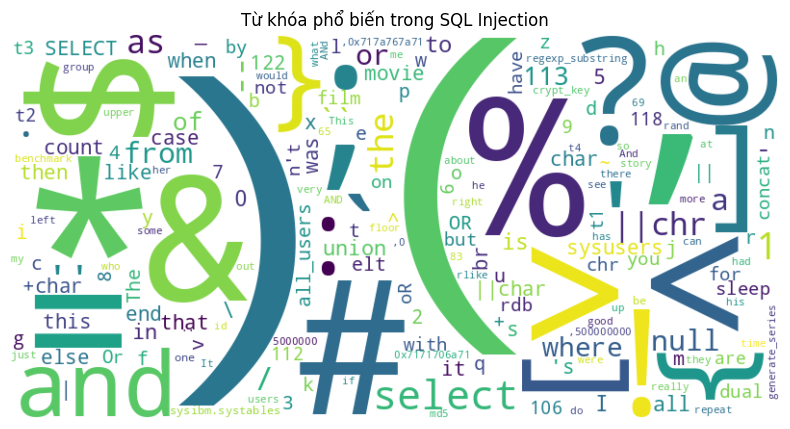

In [6]:
"""#Hiển thị từ khóa phổ biến
from collections import Counter
from wordcloud import WordCloud

sql_injection_queries = " ".join(df[df["Label"] == 1]["Query"].astype(str))
tokens = nltk.word_tokenize(sql_injection_queries)
word_freq = Counter(tokens)
wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Từ khóa phổ biến trong SQL Injection")
plt.show()
#"""

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


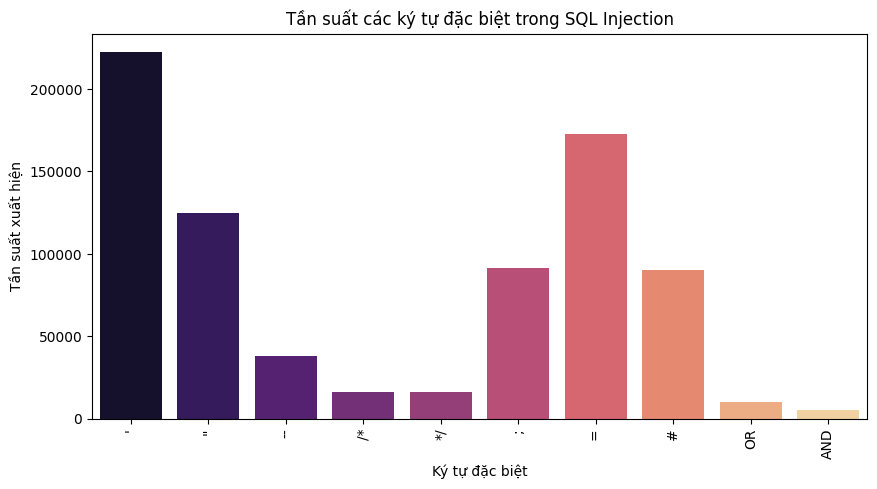

In [7]:
"""# Tần suất các kỳ tự đặc biệt
special_chars = ["'", '"', "--", "/*", "*/", ";", "=", "#", "OR", "AND"]
char_counts = {char: df["Query"].astype(str).str.count(re.escape(char)).sum() for char in special_chars}

plt.figure(figsize=(10,5))
sns.barplot(x=list(char_counts.keys()), y=list(char_counts.values()), palette="magma", )
plt.xticks(rotation=90)
plt.xlabel("Ký tự đặc biệt")
plt.ylabel("Tần suất xuất hiện")
plt.title("Tần suất các ký tự đặc biệt trong SQL Injection")
plt.show()
#"""

In [4]:
# Chia tập train (80%), validation (10%), test (10%)
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(df['Query'], df['Label'], test_size=0.2, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(test_texts, test_labels, test_size=0.5, random_state=42)

In [5]:
from transformers import DistilBertTokenizerFast

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize(texts):
    return tokenizer(texts.tolist(), padding=True, truncation=True, return_tensors="tf")

train_encodings = tokenize(train_texts)
val_encodings = tokenize(val_texts)
test_encodings = tokenize(test_texts)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

I0000 00:00:1745828769.861478      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1745828769.862440      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [6]:
from transformers import TFDistilBertModel
distil_bert = TFDistilBertModel.from_pretrained("distilbert-base-uncased")

input_ids = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="input_ids")
attention_mask = tf.keras.layers.Input(shape=(None,), dtype=tf.int32, name="attention_mask")

bert_output_shape = distil_bert.config.hidden_size
bert_output = tf.keras.layers.Lambda(
    lambda x: distil_bert(input_ids=x[0], attention_mask=x[1])[0],
    output_shape=(None, bert_output_shape)
)([input_ids, attention_mask])

# CNN layer
conv = tf.keras.layers.Conv1D(128, kernel_size=3, activation="relu")(bert_output)
pool = tf.keras.layers.GlobalMaxPooling1D()(conv)

# Output
dense = tf.keras.layers.Dense(64, activation="relu")(pool)
dropout = tf.keras.layers.Dropout(0.3)(dense)
output = tf.keras.layers.Dense(1, activation="sigmoid")(dropout)

model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model = tf.keras.Model(inputs=[input_ids, attention_mask], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_transform.weight', 'vocab_projector.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [11]:
#!rm -rf /kaggle/working/*

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create directories for checkpoints and results
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Initialize history tracking
history = {
    'epoch': [],
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'test_accuracy': [],
    'test_precision': [],
    'test_recall': [],
    'test_f1': []
}

# Define a function to evaluate on test set
def evaluate_on_test():
    # Predict on test set
    pred_probs = model.predict({
        "input_ids": test_encodings["input_ids"], 
        "attention_mask": test_encodings["attention_mask"]
    })
    preds = (pred_probs.flatten() > 0.5).astype(int)
    
    # Calculate metrics
    test_acc = accuracy_score(test_labels, preds)
    test_prec = precision_score(test_labels, preds)
    test_rec = recall_score(test_labels, preds)
    test_f1 = f1_score(test_labels, preds)
    
    return test_acc, test_prec, test_rec, test_f1, preds, pred_probs

# Define a function to save metrics and predictions
def save_results(epoch):
    # Save history to CSV
    history_df = pd.DataFrame(history)
    history_df.to_csv(f'results/training_history.csv', index=False)
    
    # Save the latest test predictions
    test_acc, test_prec, test_rec, test_f1, preds, pred_probs = evaluate_on_test()
    
    predictions_df = pd.DataFrame({
        'true_label': test_labels,
        'prediction': preds,
        'probability': pred_probs.flatten()
    })
    
    # Add metrics at the top
    metrics_df = pd.DataFrame({
        'true_label': ['METRIC', 'accuracy', 'precision', 'recall', 'f1_score'],
        'prediction': ['VALUE', test_acc, test_prec, test_rec, test_f1],
        'probability': ['', '', '', '', '']
    })
    
    combined_df = pd.concat([metrics_df, predictions_df], ignore_index=True)
    combined_df.to_csv(f'results/epoch_{epoch}_results.csv', index=False)

# Function to load previous training state if it exists
def load_training_state():
    if os.path.exists('results/training_history.csv'):
        loaded_history = pd.read_csv('results/training_history.csv')
        
        # Convert DataFrame back to dictionary
        for key in history.keys():
            history[key] = loaded_history[key].tolist()
        
        # Load the latest checkpoint
        max_epoch = max(history['epoch'])
        latest_checkpoint = f'checkpoints/model_epoch_{max_epoch}.h5'
        
        if os.path.exists(latest_checkpoint):
            model.load_weights(latest_checkpoint)
            print(f"Loaded previous training state from epoch {max_epoch}")
            return max_epoch
    
    return 0

# Load previous state if exists
start_epoch = load_training_state()

# Main training loop
MAX_EPOCHS = 100
epoch_size = 1  # Train 1 epoch at a time for better control

continue_training = True
current_epoch = start_epoch

while continue_training and current_epoch < MAX_EPOCHS:
    # Train for specified number of epochs
    for epoch in range(current_epoch + 1, current_epoch + epoch_size + 1):
        print(f"\nEpoch {epoch}/{MAX_EPOCHS}")
        
        # Train for one epoch
        batch_history = model.fit(
            x={"input_ids": train_encodings["input_ids"], "attention_mask": train_encodings["attention_mask"]},
            y=train_labels,
            validation_data=(
                {"input_ids": val_encodings["input_ids"], "attention_mask": val_encodings["attention_mask"]},
                val_labels
            ),
            epochs=1,
            batch_size=128,
            verbose=1
        )
        
        # Save checkpoint
        model.save(f'checkpoints/model_epoch_{epoch}.h5')
        
        # Update history
        history['epoch'].append(epoch)
        history['train_loss'].append(batch_history.history['loss'][0])
        history['train_accuracy'].append(batch_history.history['accuracy'][0])
        history['val_loss'].append(batch_history.history['val_loss'][0])
        history['val_accuracy'].append(batch_history.history['val_accuracy'][0])
        
        # Evaluate on test set (only on epochs divisible by 10 or last epoch)
        if epoch % 10 == 0 or epoch == MAX_EPOCHS:
            test_acc, test_prec, test_rec, test_f1, _, _ = evaluate_on_test()
            
            print(f"\nTest set evaluation at epoch {epoch}:")
            print(f"Accuracy: {test_acc:.4f}")
            print(f"Precision: {test_prec:.4f}")
            print(f"Recall: {test_rec:.4f}")
            print(f"F1 Score: {test_f1:.4f}")
            
            history['test_accuracy'].append(test_acc)
            history['test_precision'].append(test_prec)
            history['test_recall'].append(test_rec)
            history['test_f1'].append(test_f1)
        else:
            # Append None for test metrics on non-evaluation epochs
            history['test_accuracy'].append(None)
            history['test_precision'].append(None)
            history['test_recall'].append(None)
            history['test_f1'].append(None)
        
        # Save results after each epoch
        save_results(epoch)
    
    current_epoch = epoch
    
    # Ask user if they want to continue training after every 10 epochs
    if current_epoch % 10 == 0:
        # Display current performance
        print("\n" + "=" * 50)
        print(f"Training completed for {current_epoch}/{MAX_EPOCHS} epochs")
        print(f"Latest validation accuracy: {history['val_accuracy'][-1]:.4f}")
        print(f"Latest test accuracy: {test_acc:.4f}")
        print(f"Latest test F1 score: {test_f1:.4f}")
        print("=" * 50)
        
        user_input = input("\nDo you want to continue training? (yes/no): ").lower()
        continue_training = user_input.startswith('y')
        
        if not continue_training:
            print("\nTraining stopped by user. Final results have been saved.")
            break

print("\nTraining completed! All results and checkpoints have been saved.")

# Final evaluation and results
if current_epoch > 0:
    test_acc, test_prec, test_rec, test_f1, preds, pred_probs = evaluate_on_test()
    
    print("\nFinal model performance:")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Precision: {test_prec:.4f}")
    print(f"Test Recall: {test_rec:.4f}")
    print(f"Test F1 Score: {test_f1:.4f}")
    
    # Save final predictions with metrics
    predictions_df = pd.DataFrame({
        'true_label': test_labels,
        'prediction': preds,
        'probability': pred_probs.flatten()
    })
    
    metrics_df = pd.DataFrame({
        'true_label': ['METRIC', 'accuracy', 'precision', 'recall', 'f1_score'],
        'prediction': ['VALUE', test_acc, test_prec, test_rec, test_f1],
        'probability': ['', '', '', '', '']
    })
    
    combined_df = pd.concat([metrics_df, predictions_df], ignore_index=True)
    combined_df.to_csv('results/final_results.csv', index=False)
    
    print("\nFinal results saved to 'results/final_results.csv'")

Loaded previous training state from epoch 19

Epoch 20/100


I0000 00:00:1745828792.292091      99 service.cc:148] XLA service 0x7a2a540e2d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745828792.292721      99 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745828792.292739      99 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
W0000 00:00:1745828792.567879      99 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1/tf_distil_bert_model/distilbert/embeddings/assert_less/Assert/Assert
I0000 00:00:1745828793.526528      99 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1745828807.108095      99 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


927/928 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.7139 - loss: 0.5161

W0000 00:00:1745830819.032186      98 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1/tf_distil_bert_model/distilbert/embeddings/assert_less/Assert/Assert


928/928 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7139 - loss: 0.5161

...

463/464 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step

W0000 00:00:1745831349.526839      99 assert_op.cc:38] Ignoring Assert operator functional_1_1/lambda_1/tf_distil_bert_model/distilbert/embeddings/assert_less/Assert/Assert


464/464 ━━━━━━━━━━━━━━━━━━━━ 261s 551ms/step

Test set evaluation at epoch 20:
Accuracy: 0.6630
Precision: 0.6236
Recall: 0.8908
F1 Score: 0.7336
464/464 ━━━━━━━━━━━━━━━━━━━━ 250s 540ms/step

Training completed for 20/100 epochs
Latest validation accuracy: 0.6759
Latest test accuracy: 0.6630
Latest test F1 score: 0.7336



Do you want to continue training? (yes/no):  n



Training stopped by user. Final results have been saved.

Training completed! All results and checkpoints have been saved.
464/464 ━━━━━━━━━━━━━━━━━━━━ 251s 543ms/step

Final model performance:
Test Accuracy: 0.6630
Test Precision: 0.6236
Test Recall: 0.8908
Test F1 Score: 0.7336

Final results saved to 'results/final_results.csv'


In [ ]:
"""from sklearn.metrics import accuracy_score, precision_score, recall_score

# Dự đoán trên tập test
pred_probs = model.predict({
    "input_ids": test_encodings["input_ids"],
    "attention_mask": test_encodings["attention_mask"]
})
preds = (pred_probs.flatten() > 0.5).astype(int)"""

In [ ]:
"""import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(test_labels, preds)
precision = precision_score(test_labels, preds)
recall = recall_score(test_labels, preds)
f1 = f1_score(test_labels, preds)

# Create DataFrame with predictions
predictions_df = pd.DataFrame({
    'true_label': test_labels,
    'prediction': preds,
    'probability': pred_probs.flatten()
})

# Add metrics to the first rows of the DataFrame
# This creates a special section at the top of the CSV for metrics
metrics_df = pd.DataFrame({
    'true_label': ['METRIC', 'accuracy', 'precision', 'recall', 'f1_score'],
    'prediction': ['VALUE', accuracy, precision, recall, f1],
    'probability': ['', '', '', '', '']
})

# Concatenate the metrics and predictions dataframes
combined_df = pd.concat([metrics_df, predictions_df], ignore_index=True)

# Save to CSV
combined_df.to_csv('model_results.csv', index=False)

print("Predictions and metrics saved to model_results.csv")"""

In [ ]:
"""# Đánh giá
accuracy = accuracy_score(test_labels.values, preds)
precision = precision_score(test_labels.values, preds)
recall = recall_score(test_labels.values, preds)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")"""

In [ ]:
"""# Đọc tệp lịch sử huấn luyện
history_df = pd.read_csv('results/training_history.csv')

# Lọc dữ liệu mỗi 10 epoch
epochs = history_df['epoch'].values
epochs_to_plot = epochs[epochs % 10 == 0]

# Tạo hình vẽ
plt.figure(figsize=(16, 14))

# 1. Biểu đồ accuracy
plt.subplot(2, 2, 1)
plt.plot(history_df['epoch'], history_df['train_accuracy'], label='Train Accuracy')
plt.plot(history_df['epoch'], history_df['val_accuracy'], label='Validation Accuracy')

# Đánh dấu điểm mỗi 10 epoch cho accuracy
test_epochs = history_df[history_df['epoch'] % 10 == 0]['epoch']
test_accuracies = history_df[history_df['epoch'] % 10 == 0]['test_accuracy']
plt.scatter(test_epochs, test_accuracies, color='red', s=50, label='Test Accuracy (mỗi 10 epoch)')

plt.title('Accuracy qua các epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# 2. Biểu đồ loss
plt.subplot(2, 2, 2)
plt.plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
plt.plot(history_df['epoch'], history_df['val_loss'], label='Validation Loss')
plt.title('Loss qua các epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 3. Biểu đồ F1 score, precision và recall (mỗi 10 epoch)
plt.subplot(2, 2, 3)
epoch_filter = history_df['epoch'] % 10 == 0
plt.plot(history_df[epoch_filter]['epoch'], history_df[epoch_filter]['test_f1'], 'o-', label='F1 Score')
plt.plot(history_df[epoch_filter]['epoch'], history_df[epoch_filter]['test_precision'], 's-', label='Precision')
plt.plot(history_df[epoch_filter]['epoch'], history_df[epoch_filter]['test_recall'], '^-', label='Recall')
plt.title('Metrics trên tập test (mỗi 10 epoch)')
plt.xlabel('Epoch')
plt.ylabel('Giá trị')
plt.legend()
plt.grid(True)

# 4. So sánh accuracies trên 3 tập
plt.subplot(2, 2, 4)
plt.plot(history_df['epoch'], history_df['train_accuracy'], label='Train Accuracy')
plt.plot(history_df['epoch'], history_df['val_accuracy'], label='Validation Accuracy')

# Thêm giá trị test accuracy tại các điểm đã đánh giá
for i, epoch in enumerate(history_df[epoch_filter]['epoch']):
    idx = history_df[history_df['epoch'] == epoch].index[0]
    plt.axvline(x=epoch, color='gray', linestyle='--', alpha=0.3)
    
plt.scatter(test_epochs, test_accuracies, color='red', s=50, label='Test Accuracy (mỗi 10 epoch)')
plt.title('So sánh Accuracy trên các tập dữ liệu')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('results/training_visualization.png', dpi=300)
plt.show()
"""

In [ ]:
"""report = classification_report(test_labels, preds, target_names=["Normal", "SQLi"], output_dict=True)
print(classification_report(test_labels, preds, target_names=["Normal", "SQLi"]))

# Vẽ Confusion Matrix
cm = confusion_matrix(test_labels, preds)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "SQLi"], yticklabels=["Normal", "SQLi"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Vẽ biểu đồ Precision, Recall, F1-score
metrics = ["precision", "recall", "f1-score"]
classes = ["Normal", "SQLi"]

scores = [[report[cls][metric] for cls in classes] for metric in metrics]

plt.figure(figsize=(8, 5))
for i, metric in enumerate(metrics):
    plt.bar([x + i * 0.25 for x in range(len(classes))], scores[i], width=0.25, label=metric)

plt.xticks([x + 0.25 for x in range(len(classes))], classes)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Precision, Recall & F1-score per class")
plt.legend()
plt.show()"""


In [ ]:
"""#Tiền xử lí dữ liệu
MAX_VOCAB_SIZE = 5000
MAX_LENGTH = 100
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(train_texts)

train_sequences = tokenizer.texts_to_sequences(train_texts)
val_sequences = tokenizer.texts_to_sequences(val_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

X_train = pad_sequences(train_sequences, maxlen=MAX_LENGTH)
X_val = pad_sequences(val_sequences, maxlen=MAX_LENGTH)
X_test = pad_sequences(test_sequences, maxlen=MAX_LENGTH)

y_train = train_labels.values
y_val = val_labels.values
y_test = test_labels.values"""

In [ ]:
"""from sklearn.ensemble import RandomForestClassifier

# Huấn luyện mô hình RF
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

# Dự đoán và đánh giá
y_pred_rf = rf.predict(X_test)

print("Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
"""

In [ ]:
"""from tensorflow.keras.layers import LSTM, GlobalMaxPooling1D


# Xây dựng mô hình LSTM
model_lstm = Sequential([
    Embedding(MAX_VOCAB_SIZE, 128),
    LSTM(128, return_sequences=True),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile
model_lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Huấn luyện
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

# Đánh giá
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype("int32")
print("LSTM:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm):.4f}")
"""

In [ ]:
"""metrics = ['Accuracy', 'Precision', 'Recall']

CNN_distilBERT= [accuracy_score(y_test, preds), precision_score(y_test, preds), recall_score(y_test, preds)]
RF = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf), recall_score(y_test, y_pred_rf)]
LSTM = [accuracy_score(y_test, y_pred_lstm), precision_score(y_test, y_pred_lstm), recall_score(y_test, y_pred_lstm)]

x = np.arange(len(metrics))
width = 0.1

plt.figure(figsize=(10, 6))
plt.bar(x - width, CNN_distilBERT, width, label='CNN + DistilBERT Model', color='skyblue')
plt.bar(x , RF, width, label='Random Forest Model', color='lightgreen')
plt.bar(x + width, LSTM, width, label='LSTM Model', color='salmon')

# Gắn nhãn
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('So sánh mô hình ')
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
"""